<a href="https://colab.research.google.com/github/Drei-i/MachineLearningPIT/blob/main/FeatureImportance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving Rabaya(Burnout_DATASET) - Sheet1.csv to Rabaya(Burnout_DATASET) - Sheet1.csv


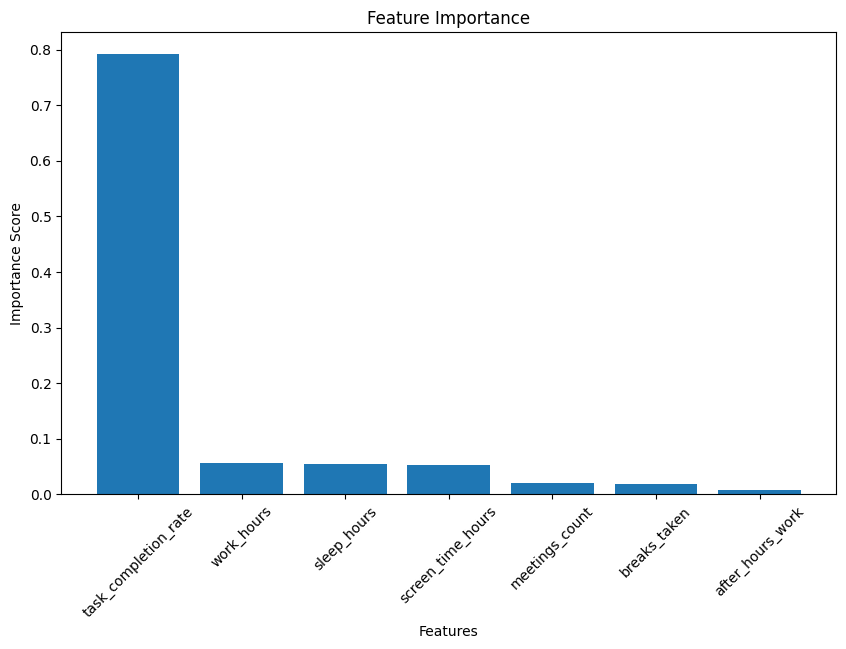

                Feature  Importance
6  task_completion_rate    0.791930
0            work_hours    0.055688
5           sleep_hours    0.054888
1     screen_time_hours    0.052612
2        meetings_count    0.019968
3          breaks_taken    0.018254
4      after_hours_work    0.006660


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# Load Dataset
from google.colab import files

# Upload Dataset Manually
uploaded = files.upload()

# Read Uploaded CSV File
file_name = list(uploaded.keys())[0]
df = pd.read_csv(file_name)

# Convert Burnout Score into Classes
median_score = df['burnout_score'].median()
df['burnout_class'] = (df['burnout_score'] >= median_score).astype(int)

# Features and Target
features = [
    'work_hours',
    'screen_time_hours',
    'meetings_count',
    'breaks_taken',
    'after_hours_work',
    'sleep_hours',
    'task_completion_rate'
]

X = df[features]
y = df['burnout_class']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train Random Forest
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# Feature Importance
importance = model.feature_importances_

# Create DataFrame
importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': importance
})

# Sort Values
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Plot
plt.figure(figsize=(10,6))
plt.bar(importance_df['Feature'], importance_df['Importance'])
plt.xticks(rotation=45)
plt.title('Feature Importance')
plt.xlabel('Features')
plt.ylabel('Importance Score')
plt.show()

print(importance_df)